# PREPARATION

**IMPORT LIBRARY**

In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


**LOAD DATA**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Membaca File
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Reviews.csv')

# INFORMASI DATASET
print("="*50)
print("INFORMASI DATASET")
print("="*50)

# Jumlah data dan kolom
print(f"Jumlah baris data : {df.shape[0]}")
print(f"Jumlah kolom      : {df.shape[1]}")

print("\nNama Kolom:")
print(df.columns.tolist())

# Menampilkan 5 data pertama
print("\nContoh 5 Data Pertama:")
print(df[['Score', 'Text']].head())


# Distribusi rating
print("\nDistribusi Rating:")
print(df['Score'].value_counts().sort_index())

INFORMASI DATASET
Jumlah baris data : 568454
Jumlah kolom      : 10

Nama Kolom:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Contoh 5 Data Pertama:
   Score                                               Text
0      5  I have bought several of the Vitality canned d...
1      1  Product arrived labeled as Jumbo Salted Peanut...
2      4  This is a confection that has been around a fe...
3      2  If you are looking for the secret ingredient i...
4      5  Great taffy at a great price.  There was a wid...

Distribusi Rating:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


In [4]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


**LABELING**

In [5]:
df = df[df['Score'] != 3].copy()

def tentukan_sentimen(nilai_score):
    if nilai_score <= 2:
        return 0 # Negatif
    elif nilai_score >= 4:
        return 1 # Positif

df['label'] = df['Score'].apply(tentukan_sentimen)

# Jumlah data setelah LABELING/membuang rating 3
print(f"Jumlah data setelah membuang rating 3 : {len(df)}")

print("\nJumlah Masing-masing Label:")
print(df['label'].value_counts())

# Contoh data hasil labeling
print("\nContoh Data Setelah Labeling:")
print(df[['Score', 'label', 'Text']].head())

Jumlah data setelah membuang rating 3 : 525814

Jumlah Masing-masing Label:
label
1    443777
0     82037
Name: count, dtype: int64

Contoh Data Setelah Labeling:
   Score  label                                               Text
0      5      1  I have bought several of the Vitality canned d...
1      1      0  Product arrived labeled as Jumbo Salted Peanut...
2      4      1  This is a confection that has been around a fe...
3      2      0  If you are looking for the secret ingredient i...
4      5      1  Great taffy at a great price.  There was a wid...


# PREPROCESSING

**Case Folding**

In [6]:
df['text_lower'] = df['Text'].astype(str).str.lower()

# Menampilkan perbandingan
contoh_index = df.index[0] # Mengambil index data pertama
print("SEBELUM (Original):")
print(df.loc[contoh_index, 'Text'])
print("\nSESUDAH (Lower Case):")
print(df.loc[contoh_index, 'text_lower'])

SEBELUM (Original):
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

SESUDAH (Lower Case):
i have bought several of the vitality canned dog food products and have found them all to be of good quality. the product looks more like a stew than a processed meat and it smells better. my labrador is finicky and she appreciates this product better than  most.


**Cleaning**

In [7]:
def clean_text(text):
      text = re.sub(r'http\S+', '', text)
      text = re.sub(r'@\w+', '', text)
      text = re.sub(r'#', '', text)
      text = re.sub(r'[^a-zA-Z\s]', '', text)
      text = re.sub(r'\s+', ' ', text).strip()
      return text

# Terapkan ke kolom text_lower
df['text_clean'] = df['text_lower'].apply(clean_text)

print("SEBELUM:")
print(df.loc[contoh_index, 'text_lower'])
print("\nSESUDAH:")
print(df.loc[contoh_index, 'text_clean'])

SEBELUM:
i have bought several of the vitality canned dog food products and have found them all to be of good quality. the product looks more like a stew than a processed meat and it smells better. my labrador is finicky and she appreciates this product better than  most.

SESUDAH:
i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it smells better my labrador is finicky and she appreciates this product better than most


**Tokenization**

In [8]:
df['text_tokenized'] = df['text_clean'].apply(word_tokenize)

print("SEBELUM:")
print(df.loc[contoh_index, 'text_clean'])
print("\nSESUDAH:")
print(df.loc[contoh_index, 'text_tokenized'])

SEBELUM:
i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it smells better my labrador is finicky and she appreciates this product better than most

SESUDAH:
['i', 'have', 'bought', 'several', 'of', 'the', 'vitality', 'canned', 'dog', 'food', 'products', 'and', 'have', 'found', 'them', 'all', 'to', 'be', 'of', 'good', 'quality', 'the', 'product', 'looks', 'more', 'like', 'a', 'stew', 'than', 'a', 'processed', 'meat', 'and', 'it', 'smells', 'better', 'my', 'labrador', 'is', 'finicky', 'and', 'she', 'appreciates', 'this', 'product', 'better', 'than', 'most']


**STOPWORD REMOVAL**

In [9]:
stop_words = set(stopwords.words('english'))
stop_words.discard('not')

def buang_stopword(tokens):
    # Hanya simpan kata yang TIDAK ada di dalam daftar stopword
    return [kata for kata in tokens if kata not in stop_words]

# VERSI 1: Dengan Stopword (tidak dilakukan stopword removal)
df['final_with_stopwords'] = df['text_tokenized'].apply(lambda x: ' '.join(x))

# VERSI 2: Tanpa Stopword (dilakukan stopword removal)
# Kolom token sementara yang sudah disaring
df['tokens_no_stopword'] = df['text_tokenized'].apply(buang_stopword)
# Gabungkan kembali menjadi kalimat
df['final_no_stopwords'] = df['tokens_no_stopword'].apply(lambda x: ' '.join(x))


print("1. Dengan Stopword:")
print(df.loc[contoh_index, 'final_with_stopwords'])
print("\n2. Tanpa Stopword:")
print(df.loc[contoh_index, 'final_no_stopwords'])

1. Dengan Stopword:
i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it smells better my labrador is finicky and she appreciates this product better than most

2. Tanpa Stopword:
bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better


**Splitting Data**

In [10]:
from sklearn.model_selection import train_test_split

X_with_stopwords = df['final_with_stopwords']
X_without_stopwords = df['final_no_stopwords']
y = df['label']

# 1. Dengan Stopword (tidak dilakukan stopword removal)
X_train_with, X_test_with, y_train, y_test = train_test_split(
    X_with_stopwords, y, test_size=0.2, random_state=42
)

# 2. Tanpa Stopword (dilakukan Stopword Removal)
X_train_without, X_test_without, _, _ = train_test_split(
    X_without_stopwords, y, test_size=0.2, random_state=42
)

print(f"""
=== DISTRIBUSI DATA ===
Total Data Keseluruhan : {df.shape[0]} review
Data Latih (80%)       : {X_train_with.shape[0]} review
Data Uji (20%)         : {X_test_with.shape[0]} review
""")


=== DISTRIBUSI DATA ===
Total Data Keseluruhan : 525814 review
Data Latih (80%)       : 420651 review
Data Uji (20%)         : 105163 review



#Representasi TF-IDF

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_with_stopwords = TfidfVectorizer()
tfidf_without_stopwords = TfidfVectorizer()

# Versi dengan Stopword (tidak dilakukan stopword removal)
X_train_with_stopwords = tfidf_with_stopwords.fit_transform(X_train_with)
X_test_with_stopwords = tfidf_with_stopwords.transform(X_test_with)

# Versi tanpa stopword (dilakukan stopword removal)
X_train_without_stopwords = tfidf_without_stopwords.fit_transform(X_train_without)
X_test_without_stopwords = tfidf_without_stopwords.transform(X_test_without)

print("\n=== INFORMASI MATRIKS TF-IDF ===")

print("=== UKURAN DATA SETELAH SPLIT DAN TF-IDF ===")
print(f"X_train_with_stopwords shape   : {X_train_with_stopwords.shape}")
print(f"X_test_with_stopwords shape    : {X_test_with_stopwords.shape}")
print(f"X_train_without_stopwords shape: {X_train_without_stopwords.shape}")
print(f"X_test_without_stopwords shape : {X_test_without_stopwords.shape}")

print("="*60)

# MELIHAT ISI REPRESENTASI TF-IDF

print("\n=== CONTOH REPRESENTASI TF-IDF UNTUK 1 REVIEW ===")

# Ambil 1 review contoh
sample_index = 0

original_text = df.iloc[sample_index]['Text']
clean_text = df.iloc[sample_index]['final_no_stopwords']

print(f"\nTeks Original:\n{original_text[:200]}...")
print(f"\nTeks Setelah Preprocessing:\n{clean_text}")

# Mengambil vektor TF-IDF review tersebut
sample_vector = X_train_without_stopwords[sample_index]

# Mengambil daftar seluruh fitur/kata
feature_names = tfidf_without_stopwords.get_feature_names_out()

# Mencari indeks kata yang muncul
non_zero_indices = sample_vector.nonzero()[1]

# Menyusun kata dan nilai TF-IDF
tfidf_values = []

for feature_index in non_zero_indices:

    feature_word = feature_names[feature_index]
    tfidf_score = sample_vector[0, feature_index]

    tfidf_values.append({
        'Kata (Fitur)': feature_word,
        'Nilai TF-IDF': round(tfidf_score, 4)
    })

# Membuat dataframe hasil
df_tfidf_preview = pd.DataFrame(tfidf_values)

# Urutkan dari nilai terbesar
df_tfidf_preview = df_tfidf_preview.sort_values(
    by='Nilai TF-IDF',
    ascending=False
)

print("\n=== FITUR YANG MEMBENTUK REVIEW TERSEBUT ===")

display(df_tfidf_preview)


=== INFORMASI MATRIKS TF-IDF ===
=== UKURAN DATA SETELAH SPLIT DAN TF-IDF ===
X_train_with_stopwords shape   : (420651, 182499)
X_test_with_stopwords shape    : (105163, 182499)
X_train_without_stopwords shape: (420651, 182362)
X_test_without_stopwords shape : (105163, 182362)

=== CONTOH REPRESENTASI TF-IDF UNTUK 1 REVIEW ===

Teks Original:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador...

Teks Setelah Preprocessing:
bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better

=== FITUR YANG MEMBENTUK REVIEW TERSEBUT ===


,Kata (Fitur),Nilai TF-IDF
3,almonds,0.6140
6,planning,0.4030
9,nuts,0.2833
8,plus,0.2572
10,company,0.2477
4,large,0.2473
2,money,0.2429
5,whole,0.2197
7,order,0.1989
1,buy,0.1677


# Model 1 - Data Imballance Tanpa Perlakuan

**PELATIHAN MODEL**

In [12]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi dua model yang identik
model1_with = LogisticRegression(max_iter=1000, random_state=42)
model1_without = LogisticRegression(max_iter=1000, random_state=42)

# Training
model1_with.fit(X_train_with_stopwords, y_train)

model1_without.fit(X_train_without_stopwords, y_train)

print("\nTraining model selesai")


Training model selesai


**Evaluasi**

In [13]:
from sklearn.metrics import accuracy_score, classification_report

print("=== HASIL UJI & METRIK EVALUASI ===\n")

# --- 1. UJI MODEL DENGAN STOPWORD ---
prediksi1_with = model1_with.predict(X_test_with_stopwords)
akurasi_with = accuracy_score(y_test, prediksi1_with)

print("==================================================")
print(f"AKURASI MODEL DENGAN STOPWORD : {akurasi_with * 100:.2f}%")
print("==================================================")
print("Detail Metrik (Dengan Stopword):")
print(classification_report(y_test, prediksi1_with, target_names=['Negatif (0)', 'Positif (1)']))


# --- 2. UJI MODEL TANPA STOPWORD ---
prediksi1_without = model1_without.predict(X_test_without_stopwords)
akurasi_without = accuracy_score(y_test, prediksi1_without)

print("\n==================================================")
print(f"AKURASI MODEL TANPA STOPWORD  : {akurasi_without * 100:.2f}%")
print("==================================================")
print("Detail Metrik (Tanpa Stopword):")
print(classification_report(y_test, prediksi1_without, target_names=['Negatif (0)', 'Positif (1)']))

=== HASIL UJI & METRIK EVALUASI ===

AKURASI MODEL DENGAN STOPWORD : 93.91%
Detail Metrik (Dengan Stopword):
              precision    recall  f1-score   support

 Negatif (0)       0.87      0.72      0.79     16379
 Positif (1)       0.95      0.98      0.96     88784

    accuracy                           0.94    105163
   macro avg       0.91      0.85      0.88    105163
weighted avg       0.94      0.94      0.94    105163


AKURASI MODEL TANPA STOPWORD  : 93.88%
Detail Metrik (Tanpa Stopword):
              precision    recall  f1-score   support

 Negatif (0)       0.86      0.72      0.79     16379
 Positif (1)       0.95      0.98      0.96     88784

    accuracy                           0.94    105163
   macro avg       0.91      0.85      0.88    105163
weighted avg       0.94      0.94      0.94    105163



**Confusion Matrix**

=== VISUALISASI CONFUSION MATRIX ===



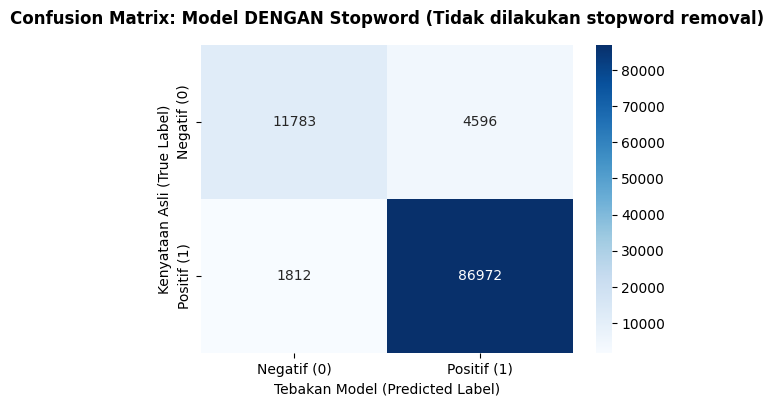

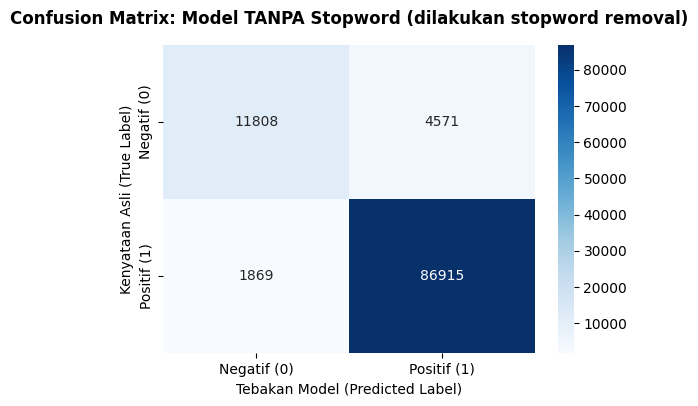

In [14]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title):
    # Membuat matriks konfusi
    cm = confusion_matrix(y_true, y_pred)

    # Membuat visualisasi heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negatif (0)', 'Positif (1)'],
                yticklabels=['Negatif (0)', 'Positif (1)'])

    # Menambahkan label
    plt.title(title, pad=15, fontweight='bold')
    plt.xlabel('Tebakan Model (Predicted Label)')
    plt.ylabel('Kenyataan Asli (True Label)')
    plt.show()

print("=== VISUALISASI CONFUSION MATRIX ===\n")

# 1. Menampilkan Matriks untuk Model DENGAN Stopword
plot_confusion_matrix(y_test, prediksi1_with, "Confusion Matrix: Model DENGAN Stopword (Tidak dilakukan stopword removal)")

# 2. Menampilkan Matriks untuk Model TANPA Stopword
plot_confusion_matrix(y_test, prediksi1_without, "Confusion Matrix: Model TANPA Stopword (dilakukan stopword removal)")

**KURVA ROC AUC**

=== SKOR & VISUALISASI ROC-AUC MODEL 1 ===
ROC-AUC (DENGAN Stopword / Teks Utuh)  : 0.9688
ROC-AUC (TANPA Stopword / Teks Bersih) : 0.9683



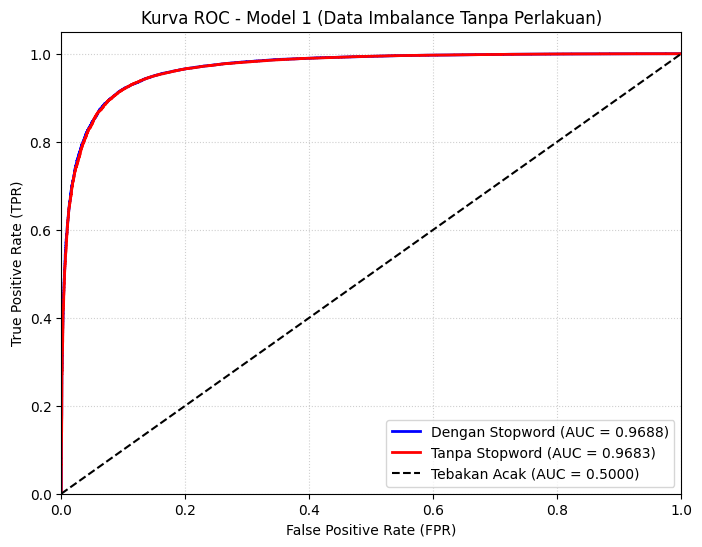

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

print("=== SKOR & VISUALISASI ROC-AUC MODEL 1 ===")

# 1. Ambil Probabilitas tebakan kelas 1 (Positif)
prob_with = model1_with.predict_proba(X_test_with_stopwords)[:, 1]
prob_without = model1_without.predict_proba(X_test_without_stopwords)[:, 1]

# 2. Hitung nilai nominal skor AUC
auc_with = roc_auc_score(y_test, prob_with)
auc_without = roc_auc_score(y_test, prob_without)

print(f"ROC-AUC (DENGAN Stopword / Teks Utuh)  : {auc_with:.4f}")
print(f"ROC-AUC (TANPA Stopword / Teks Bersih) : {auc_without:.4f}\n")

# 3. Hitung FPR dan TPR untuk penggambaran grafik kurva
fpr_with, tpr_with, _ = roc_curve(y_test, prob_with)
fpr_without, tpr_without, _ = roc_curve(y_test, prob_without)

# 4. Pembuatan Grafik Komparasi
plt.figure(figsize=(8, 6))
plt.plot(fpr_with, tpr_with, color='blue', lw=2, label=f'Dengan Stopword (AUC = {auc_with:.4f})')
plt.plot(fpr_without, tpr_without, color='red', lw=2, label=f'Tanpa Stopword (AUC = {auc_without:.4f})')

# Garis bantu diagonal tebakan acak (standar validasi ROC)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Tebakan Acak (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Kurva ROC - Model 1 (Data Imbalance Tanpa Perlakuan)')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Model 2 - SMOTE

Perlakuan SMOTE

In [16]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_sm_with, y_train_sm = sm.fit_resample(X_train_with_stopwords, y_train)
X_train_sm_without, y_train_sm = sm.fit_resample(X_train_without_stopwords, y_train)
print(pd.Series(y_train_sm).value_counts())

label
1    354993
0    354993
Name: count, dtype: int64


Training Model

In [17]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi dua model yang identik
model2_with = LogisticRegression(max_iter=1000, random_state=42)
model2_without = LogisticRegression(max_iter=1000, random_state=42)

# Training
model2_with.fit(X_train_sm_with, y_train_sm)

model2_without.fit(X_train_sm_without, y_train_sm)

print("\nTraining model selesai")


Training model selesai


Evaluasi Model 2 - SMOTE

In [18]:
from sklearn.metrics import accuracy_score, classification_report

print("=== HASIL UJI & METRIK EVALUASI ===\n")

# --- 1. UJI MODEL DENGAN STOPWORD REMOVAL ---
prediksi2_with = model2_with.predict(X_test_with_stopwords)
akurasi_with = accuracy_score(y_test, prediksi2_with)

print("==================================================")
print(f"AKURASI MODEL DENGAN STOPWORD (tidak dilakukan Stopword Removal) : {akurasi_with * 100:.2f}%")
print("==================================================")
print("Detail Metrik:")
print(classification_report(y_test, prediksi2_with, target_names=['Negatif (0)', 'Positif (1)']))


# --- 2. UJI MODEL TANPA STOPWORD REMOVAL---
prediksi2_without = model2_without.predict(X_test_without_stopwords)
akurasi_without = accuracy_score(y_test, prediksi2_without)

print("\n==================================================")
print(f"AKURASI MODEL TANPA STOPWORD (dilakukan Stopword Removal): {akurasi_without * 100:.2f}%")
print("==================================================")
print("Detail Metrik:")
print(classification_report(y_test, prediksi2_without, target_names=['Negatif (0)', 'Positif (1)']))

=== HASIL UJI & METRIK EVALUASI ===

AKURASI MODEL DENGAN STOPWORD (tidak dilakukan Stopword Removal) : 92.53%
Detail Metrik:
              precision    recall  f1-score   support

 Negatif (0)       0.70      0.90      0.79     16379
 Positif (1)       0.98      0.93      0.95     88784

    accuracy                           0.93    105163
   macro avg       0.84      0.91      0.87    105163
weighted avg       0.94      0.93      0.93    105163


AKURASI MODEL TANPA STOPWORD (dilakukan Stopword Removal): 92.28%
Detail Metrik:
              precision    recall  f1-score   support

 Negatif (0)       0.70      0.89      0.78     16379
 Positif (1)       0.98      0.93      0.95     88784

    accuracy                           0.92    105163
   macro avg       0.84      0.91      0.87    105163
weighted avg       0.94      0.92      0.93    105163



Confussion Matrix Model 2 - SMOTE

=== VISUALISASI CONFUSION MATRIX ===



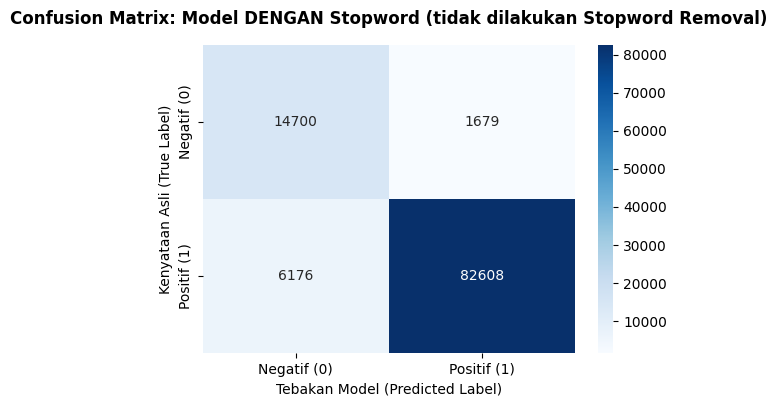

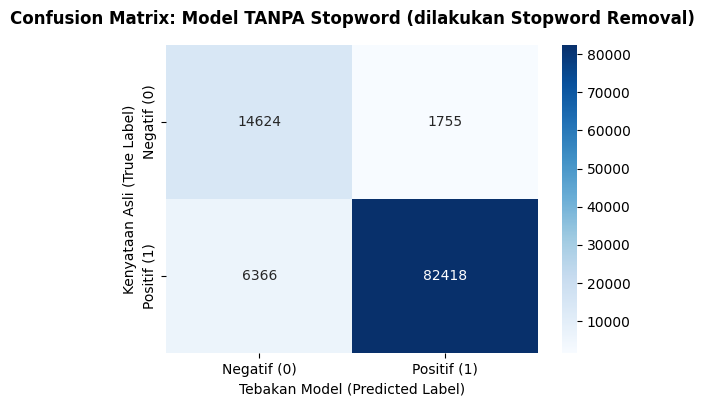

In [19]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title):
    # Membuat matriks konfusi
    cm = confusion_matrix(y_true, y_pred)

    # Membuat visualisasi heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negatif (0)', 'Positif (1)'],
                yticklabels=['Negatif (0)', 'Positif (1)'])

    # Menambahkan label
    plt.title(title, pad=15, fontweight='bold')
    plt.xlabel('Tebakan Model (Predicted Label)')
    plt.ylabel('Kenyataan Asli (True Label)')
    plt.show()

print("=== VISUALISASI CONFUSION MATRIX ===\n")

# 1. Menampilkan Matriks untuk Model DENGAN Stopword
plot_confusion_matrix(y_test, prediksi2_with, "Confusion Matrix: Model DENGAN Stopword (tidak dilakukan Stopword Removal)")

# 2. Menampilkan Matriks untuk Model TANPA Stopword
plot_confusion_matrix(y_test, prediksi2_without, "Confusion Matrix: Model TANPA Stopword (dilakukan Stopword Removal)")

**Kurva ROC AUC Model 2**

=== SKOR & VISUALISASI ROC-AUC MODEL 2 (SMOTE) ===
ROC-AUC (DENGAN Stopword / Teks Utuh)  : 0.9711
ROC-AUC (TANPA Stopword / Teks Bersih) : 0.9696



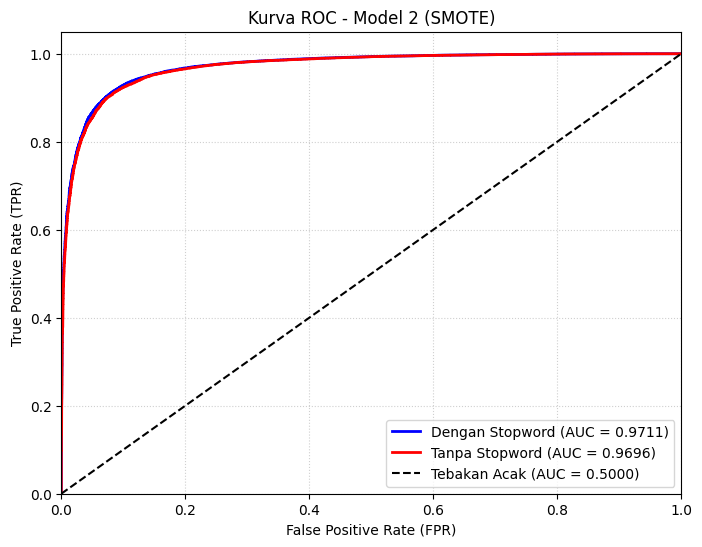

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

print("=== SKOR & VISUALISASI ROC-AUC MODEL 2 (SMOTE) ===")

# 1. Ambil Probabilitas dari Model 2
prob_with = model2_with.predict_proba(X_test_with_stopwords)[:, 1]
prob_without = model2_without.predict_proba(X_test_without_stopwords)[:, 1]

# 2. Hitung nilai nominal skor AUC
auc_with = roc_auc_score(y_test, prob_with)
auc_without = roc_auc_score(y_test, prob_without)

print(f"ROC-AUC (DENGAN Stopword / Teks Utuh)  : {auc_with:.4f}")
print(f"ROC-AUC (TANPA Stopword / Teks Bersih) : {auc_without:.4f}\n")

# 3. Hitung FPR dan TPR
fpr_with, tpr_with, _ = roc_curve(y_test, prob_with)
fpr_without, tpr_without, _ = roc_curve(y_test, prob_without)

# 4. Pembuatan Grafik Komparasi
plt.figure(figsize=(8, 6))
plt.plot(fpr_with, tpr_with, color='blue', lw=2, label=f'Dengan Stopword (AUC = {auc_with:.4f})')
plt.plot(fpr_without, tpr_without, color='red', lw=2, label=f'Tanpa Stopword (AUC = {auc_without:.4f})')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Tebakan Acak (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Kurva ROC - Model 2 (SMOTE)')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Model 3 - K-Fold Cross Validation & Loss Function

**K-FOLD CROSS VALIDATION**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
# Menyiapkan skema 5-Fold Cross Validation yang menjaga distribusi kelas tetap seimbang
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Membuat Pipeline agar proses fit TF-IDF HANYA terjadi pada fold training di setiap iterasi (Bebas Data Leakage)
pipeline_with = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

pipeline_without = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

print("=== MEMULAI 5-FOLD CROSS VALIDATION (METRIK: F1-MACRO) ===\n")

skor_cv_with = cross_val_score(pipeline_with, X_train_with, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
print("Data dengan Stopword (Teks utuh, tidak dilakukan stopword removal):")
for i, skor in enumerate(skor_cv_with):
    print(f"   Fold-{i+1} : {skor * 100:.2f}%")
print(f"   RATA-RATA: {skor_cv_with.mean() * 100:.2f}%\n")

skor_cv_without = cross_val_score(pipeline_without, X_train_without, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
print("Data tanpa Stopword (Teks bersih, dilakukan stopword removal):")
for i, skor in enumerate(skor_cv_without):
    print(f"   Fold-{i+1} : {skor * 100:.2f}%")
print(f"   RATA-RATA: {skor_cv_without.mean() * 100:.2f}%")

=== MEMULAI 5-FOLD CROSS VALIDATION (METRIK: F1-MACRO) ===

Data dengan Stopword (Teks utuh, tidak dilakukan stopword removal):
   Fold-1 : 85.98%
   Fold-2 : 85.22%
   Fold-3 : 85.68%
   Fold-4 : 85.24%
   Fold-5 : 85.39%
   RATA-RATA: 85.50%

Data tanpa Stopword (Teks bersih, dilakukan stopword removal):
   Fold-1 : 85.64%
   Fold-2 : 85.30%
   Fold-3 : 85.58%
   Fold-4 : 85.36%
   Fold-5 : 85.08%
   RATA-RATA: 85.39%


**Evaluasi K-Fold**

In [22]:
from sklearn.metrics import accuracy_score, classification_report

print("=== HASIL UJI & METRIK EVALUASI ===\n")

# Fit the pipelines on the full training data before making predictions
# --- 1. Fit MODEL DENGAN STOPWORD ---
pipeline_with.fit(X_train_with, y_train)

# --- 2. Fit MODEL TANPA STOPWORD ---
pipeline_without.fit(X_train_without, y_train)

# --- 1. UJI MODEL DENGAN STOPWORD ---
prediksi3_with = pipeline_with.predict(X_test_with)
akurasi_with = accuracy_score(y_test, prediksi3_with)

print("==================================================")
print(f"AKURASI MODEL Dengan STOPWORD (Tidak dilakukan Stopword Removal) : {akurasi_with * 100:.2f}%")
print("==================================================")
print("Detail Metrik (Dengan Stopword):")
print(classification_report(y_test, prediksi3_with, target_names=['Negatif (0)', 'Positif (1)']))


# --- 2. UJI MODEL TANPA STOPWORD ---
prediksi3_without = pipeline_without.predict(X_test_without)
akurasi_without = accuracy_score(y_test, prediksi3_without)

print("\n==================================================")
print(f"AKURASI MODEL TANPA STOPWORD (dilakukan Stopword Removal) : {akurasi_without * 100:.2f}%")
print("==================================================")
print("Detail Metrik:")
print(classification_report(y_test, prediksi3_without, target_names=['Negatif (0)', 'Positif (1)']))

=== HASIL UJI & METRIK EVALUASI ===

AKURASI MODEL Dengan STOPWORD (Tidak dilakukan Stopword Removal) : 91.58%
Detail Metrik (Dengan Stopword):
              precision    recall  f1-score   support

 Negatif (0)       0.67      0.91      0.77     16379
 Positif (1)       0.98      0.92      0.95     88784

    accuracy                           0.92    105163
   macro avg       0.83      0.92      0.86    105163
weighted avg       0.93      0.92      0.92    105163


AKURASI MODEL TANPA STOPWORD (dilakukan Stopword Removal) : 91.50%
Detail Metrik:
              precision    recall  f1-score   support

 Negatif (0)       0.67      0.91      0.77     16379
 Positif (1)       0.98      0.92      0.95     88784

    accuracy                           0.91    105163
   macro avg       0.82      0.91      0.86    105163
weighted avg       0.93      0.91      0.92    105163



Confusion Matrix Model 3 - K-Fold & Loss Function

=== VISUALISASI CONFUSION MATRIX ===



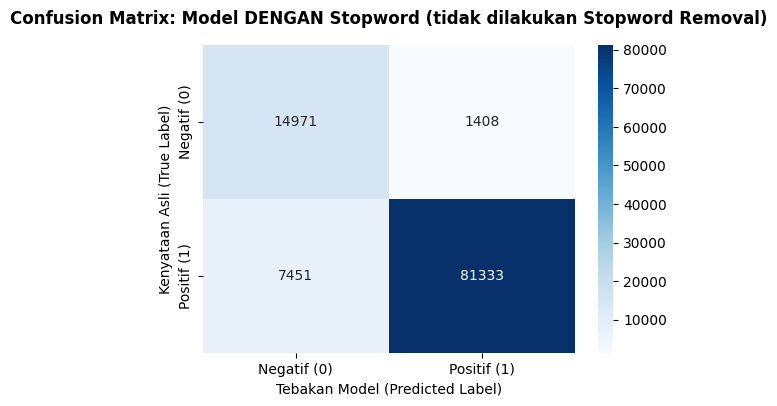

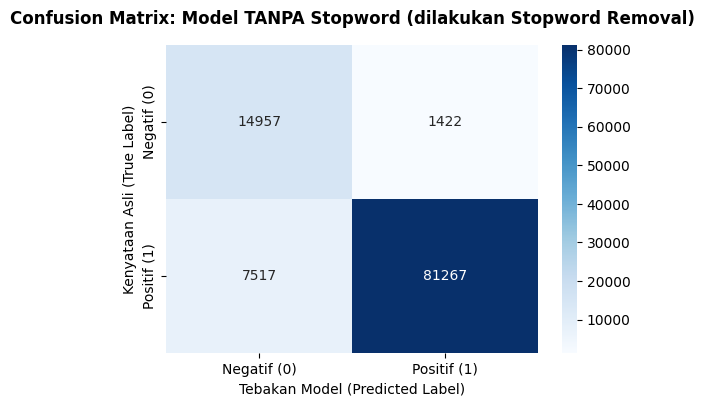

In [23]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title):
    # Membuat matriks konfusi
    cm = confusion_matrix(y_true, y_pred)

    # Membuat visualisasi heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negatif (0)', 'Positif (1)'],
                yticklabels=['Negatif (0)', 'Positif (1)'])

    # Menambahkan label
    plt.title(title, pad=15, fontweight='bold')
    plt.xlabel('Tebakan Model (Predicted Label)')
    plt.ylabel('Kenyataan Asli (True Label)')
    plt.show()

print("=== VISUALISASI CONFUSION MATRIX ===\n")

# 1. Menampilkan Matriks untuk Model DENGAN Stopword Removal
plot_confusion_matrix(y_test, prediksi3_with, "Confusion Matrix: Model DENGAN Stopword (tidak dilakukan Stopword Removal)")

# 2. Menampilkan Matriks untuk Model TANPA Stopword Removal
plot_confusion_matrix(y_test, prediksi3_without, "Confusion Matrix: Model TANPA Stopword (dilakukan Stopword Removal)")

**Kurva ROC AUC Model 3**

=== SKOR & VISUALISASI ROC-AUC MODEL 3 (K-FOLD & PIPELINE) ===
ROC-AUC (DENGAN Stopword / Teks Utuh)  : 0.9708
ROC-AUC (TANPA Stopword / Teks Bersih) : 0.9698



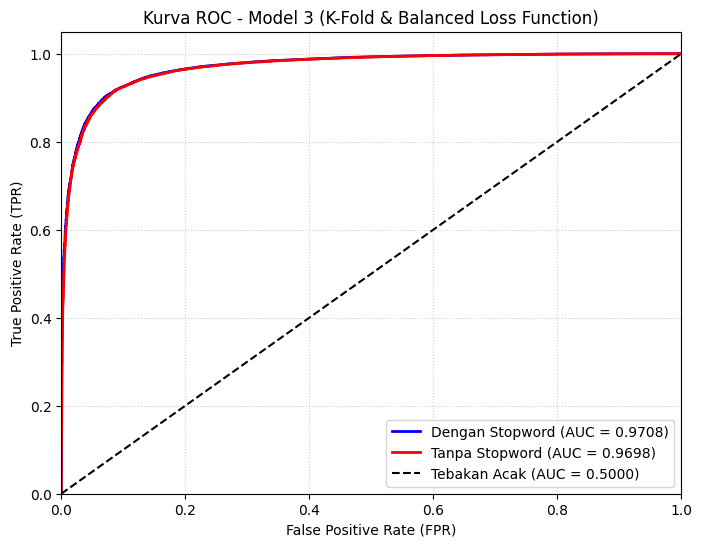

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

print("=== SKOR & VISUALISASI ROC-AUC MODEL 3 (K-FOLD & PIPELINE) ===")

# 1. Ambil Probabilitas LANGSUNG lewat objek Pipeline menggunakan teks asli
prob_with = pipeline_with.predict_proba(X_test_with)[:, 1]
prob_without = pipeline_without.predict_proba(X_test_without)[:, 1]

# 2. Hitung nilai nominal skor AUC
auc_with = roc_auc_score(y_test, prob_with)
auc_without = roc_auc_score(y_test, prob_without)

print(f"ROC-AUC (DENGAN Stopword / Teks Utuh)  : {auc_with:.4f}")
print(f"ROC-AUC (TANPA Stopword / Teks Bersih) : {auc_without:.4f}\n")

# 3. Hitung FPR dan TPR
fpr_with, tpr_with, _ = roc_curve(y_test, prob_with)
fpr_without, tpr_without, _ = roc_curve(y_test, prob_without)

# 4. Pembuatan Grafik Komparasi
plt.figure(figsize=(8, 6))
plt.plot(fpr_with, tpr_with, color='blue', lw=2, label=f'Dengan Stopword (AUC = {auc_with:.4f})')
plt.plot(fpr_without, tpr_without, color='red', lw=2, label=f'Tanpa Stopword (AUC = {auc_without:.4f})')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Tebakan Acak (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Kurva ROC - Model 3 (K-Fold & Balanced Loss Function)')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Analisis Bobot & Missmatch

**BOBOT MODEL 1**

In [25]:
def analisis_bobot_model(vectorizer, model, judul):
    # Mengambil daftar kata dan nilai bobotnya
    fitur_kata = vectorizer.get_feature_names_out()
    bobot_kata = model.coef_[0]

    # Memasukkan ke dalam tabel (DataFrame)
    df_analisis = pd.DataFrame({
        'Kata': fitur_kata,
        'Bobot': bobot_kata
    })

    # Mengurutkan berdasarkan bobot tertinggi ke terendah
    df_urut = df_analisis.sort_values(by='Bobot', ascending=False)

    print(f"\n{judul}")
    print("-" * 50)
    print("10 KATA POSITIF TERTINGGI (Mendorong tebakan ke Kelas 1)")
    display(df_urut.head(10).reset_index(drop=True))

    print("\n10 KATA NEGATIF TERTINGGI(Mendorong tebakan ke Kelas 0)")
    display(df_urut.tail(10).sort_values(by='Bobot').reset_index(drop=True))
    print("=" * 50)

# 1. model DENGAN Stopword
analisis_bobot_model(tfidf_with_stopwords, model1_with, "=== BOBOT: MODEL DENGAN STOPWORD ===")

# 2. model TANPA Stopword
analisis_bobot_model(tfidf_without_stopwords, model1_without, "=== BOBOT: MODEL TANPA STOPWORD ===")


=== BOBOT: MODEL DENGAN STOPWORD ===
--------------------------------------------------
10 KATA POSITIF TERTINGGI (Mendorong tebakan ke Kelas 1)


,Kata,Bobot
0,great,15.392765
1,delicious,13.253364
2,perfect,12.626639
3,best,12.277705
4,excellent,10.103644
5,love,9.249328
6,good,9.225121
7,amazing,9.039806
8,highly,9.025670
9,wonderful,8.791631



10 KATA NEGATIF TERTINGGI(Mendorong tebakan ke Kelas 0)


,Kata,Bobot
0,worst,-13.699023
1,disappointing,-11.910433
2,disappointment,-9.900293
3,terrible,-9.649920
4,not,-9.472443
5,awful,-9.323341
6,disappointed,-9.071242
7,unfortunately,-8.104266
8,threw,-8.044648
9,yuck,-7.788723



=== BOBOT: MODEL TANPA STOPWORD ===
--------------------------------------------------
10 KATA POSITIF TERTINGGI (Mendorong tebakan ke Kelas 1)


,Kata,Bobot
0,great,14.569862
1,best,12.903691
2,delicious,12.714108
3,perfect,11.727000
4,excellent,9.615689
5,loves,9.491973
6,highly,8.891856
7,good,8.685945
8,amazing,8.601844
9,wonderful,8.399789



10 KATA NEGATIF TERTINGGI(Mendorong tebakan ke Kelas 0)


,Kata,Bobot
0,worst,-12.775329
1,disappointing,-11.271981
2,disappointment,-9.540967
3,terrible,-9.376786
4,not,-9.337861
5,awful,-8.796751
6,disappointed,-8.605543
7,unfortunately,-7.982150
8,threw,-7.813887
9,horrible,-7.428601


Visualisasi Bobot Model 1

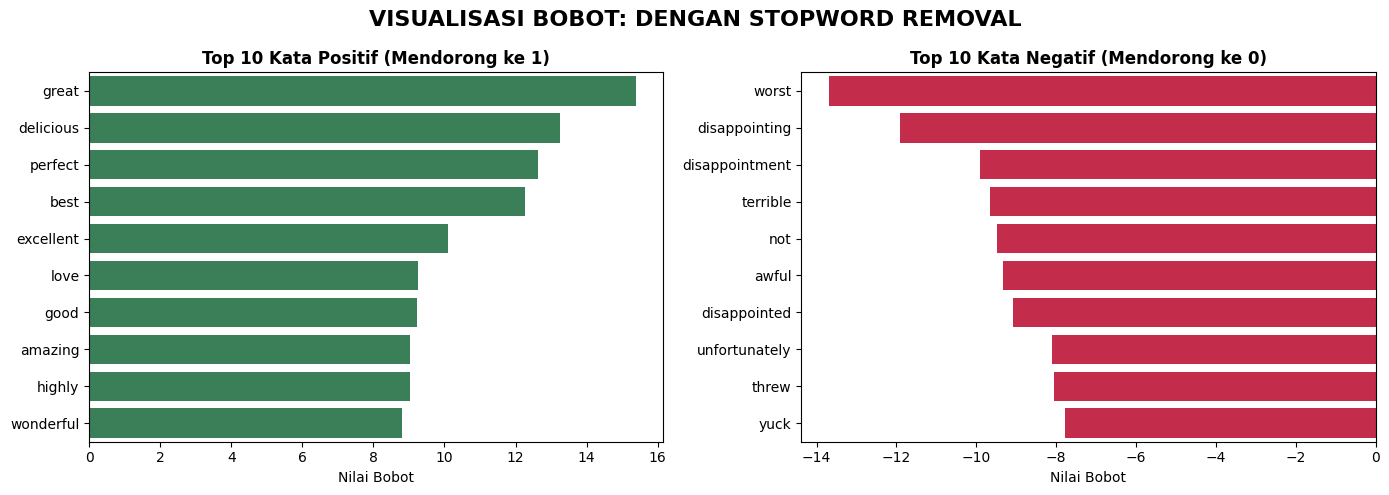

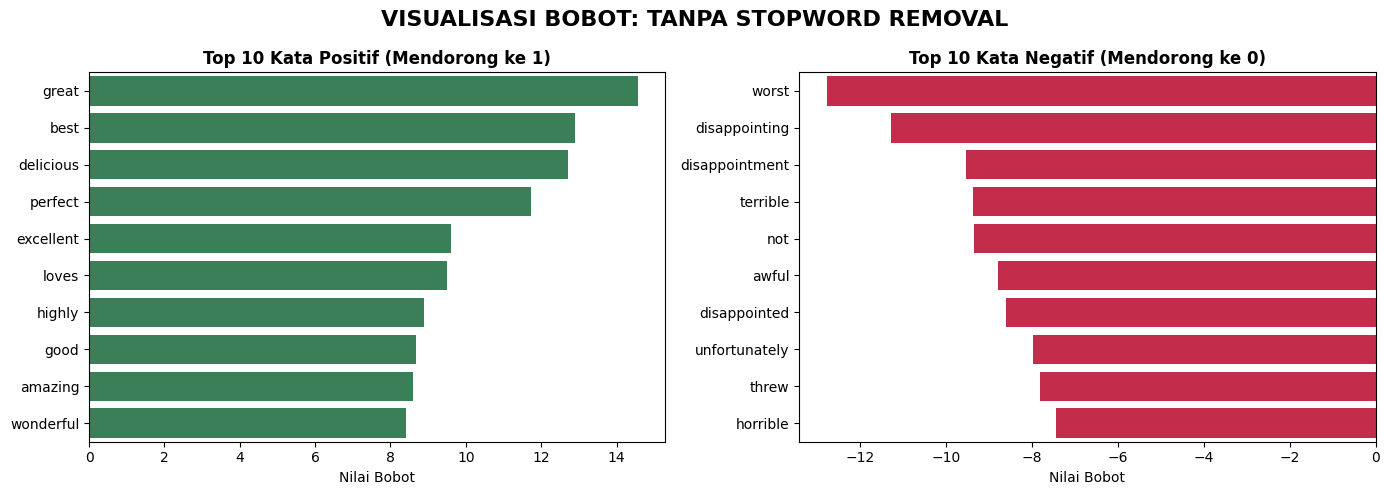

In [26]:
def visualisasi_bobot_model(vectorizer, model, judul):
    # 1. Mengambil kata dan bobot
    fitur_kata = vectorizer.get_feature_names_out()
    bobot_kata = model.coef_[0]

    df_analisis = pd.DataFrame({'Kata': fitur_kata, 'Bobot': bobot_kata})
    df_urut = df_analisis.sort_values(by='Bobot', ascending=False)

    # 2. Pisahkan Top 10 Positif dan Top 10 Negatif
    top_positif = df_urut.head(10)
    top_negatif = df_urut.tail(10).sort_values(by='Bobot', ascending=True) # Urutkan dari minus terdalam

    # 3. Membuat Canvas Visualisasi (1 baris, 2 kolom)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(judul, fontsize=16, fontweight='bold')

    # Grafik Kiri: Kata Positif (Warna Hijau)
    sns.barplot(x='Bobot', y='Kata', data=top_positif, ax=axes[0], color='seagreen')
    axes[0].set_title('Top 10 Kata Positif (Mendorong ke 1)', fontweight='bold')
    axes[0].set_xlabel('Nilai Bobot')
    axes[0].set_ylabel('')

    # Grafik Kanan: Kata Negatif (Warna Merah)
    sns.barplot(x='Bobot', y='Kata', data=top_negatif, ax=axes[1], color='crimson')
    axes[1].set_title('Top 10 Kata Negatif (Mendorong ke 0)', fontweight='bold')
    axes[1].set_xlabel('Nilai Bobot')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

# Panggil fungsinya
visualisasi_bobot_model(tfidf_with_stopwords, model1_with, "VISUALISASI BOBOT: DENGAN STOPWORD REMOVAL")
visualisasi_bobot_model(tfidf_without_stopwords, model1_without, "VISUALISASI BOBOT: TANPA STOPWORD REMOVAL")

**Analisis Missmatch (model 1)**

In [27]:
# Membuat Dataframe untuk memetakan teks asli dengan label aktual dan hasil prediksi
df_mismatch = pd.DataFrame({
    'Teks_Asli': df.loc[X_test_without.index, 'Text'],
    'Label_Asli': y_test,
    'Prediksi': prediksi1_without
})

# Menyaring data di mana label asli TIDAK SAMA dengan hasil prediksi
mismatch_data = df_mismatch[df_mismatch['Label_Asli'] != df_mismatch['Prediksi']]

print(f"=== ANALISIS MISMATCH (ERROR ANALYSIS) ===")
print(f"Total ulasan yang salah tebak: {len(mismatch_data)} dari {len(X_test_without)} data uji.\n")

print("1. CONTOH FALSE POSITIVE (Ulasan Aslinya NEGATIF, tapi Ditebak POSITIF oleh Model):")
fp_samples = mismatch_data[mismatch_data['Label_Asli'] == 0].head(3)
for idx, row in fp_samples.iterrows():
    print(f"[-] {row['Teks_Asli']}\n")
print("="*80)

print("\n2. CONTOH FALSE NEGATIVE (Ulasan Aslinya POSITIF, tapi Ditebak NEGATIF oleh Model):")
fn_samples = mismatch_data[mismatch_data['Label_Asli'] == 1].head(3)
for idx, row in fn_samples.iterrows():
    print(f"[+] {row['Teks_Asli']}\n")

=== ANALISIS MISMATCH (ERROR ANALYSIS) ===
Total ulasan yang salah tebak: 6440 dari 105163 data uji.

1. CONTOH FALSE POSITIVE (Ulasan Aslinya NEGATIF, tapi Ditebak POSITIF oleh Model):
[-] I really wanted this to work...we have had major problems with various critters eating our garden this year...most of our plants have been stripped, nibbled to nubs, dug up, or eaten as seeds.  For certain there are some rabbits, some mice, some birds, chipmunks and lizards involved here to varying degrees.  This just flat didn't help. This was no more effective than sprinkling cayenne, spraying garlic or anything else we've tried.  It's a nice big bottled filled with stinky powder that doesn't do anything more than use up some money that could feed a nice snake for the garden, dog for the yard, or cat to attack visiting rodents.  I've tried way too many sprays and powders by now and am moving on to fences and hanging baskets.  For a minor problem this may be worth something to someone...though I'd 

**BOBOT MODEL 2**

In [28]:
def analisis_bobot_model(vectorizer, model, judul):
    # Mengambil daftar kata dan nilai bobotnya
    fitur_kata = vectorizer.get_feature_names_out()
    bobot_kata = model.coef_[0]

    # Memasukkan ke dalam tabel (DataFrame)
    df_analisis = pd.DataFrame({
        'Kata': fitur_kata,
        'Bobot': bobot_kata
    })

    # Mengurutkan berdasarkan bobot tertinggi ke terendah
    df_urut = df_analisis.sort_values(by='Bobot', ascending=False)

    print(f"\n{judul}")
    print("-" * 50)
    print("10 KATA POSITIF TERTINGGI (Mendorong tebakan ke Kelas 1)")
    display(df_urut.head(10).reset_index(drop=True))

    print("\n10 KATA NEGATIF TERTINGGI(Mendorong tebakan ke Kelas 0)")
    display(df_urut.tail(10).sort_values(by='Bobot').reset_index(drop=True))
    print("=" * 50)

# 1. model DENGAN Stopword
analisis_bobot_model(tfidf_with_stopwords, model2_with, "=== BOBOT: MODEL DENGAN STOPWORD ===")

# 2. model TANPA Stopword
analisis_bobot_model(tfidf_without_stopwords, model2_without, "=== BOBOT: MODEL TANPA STOPWORD ===")


=== BOBOT: MODEL DENGAN STOPWORD ===
--------------------------------------------------
10 KATA POSITIF TERTINGGI (Mendorong tebakan ke Kelas 1)


,Kata,Bobot
0,great,17.043934
1,delicious,16.144619
2,best,14.709677
3,perfect,14.694196
4,pleasantly,12.317683
5,excellent,11.289864
6,hooked,10.896773
7,highly,10.842645
8,skeptical,10.407577
9,good,10.217083



10 KATA NEGATIF TERTINGGI(Mendorong tebakan ke Kelas 0)


,Kata,Bobot
0,worst,-15.815808
1,disappointing,-14.291296
2,not,-12.340098
3,terrible,-11.661009
4,disappointment,-11.655767
5,unfortunately,-11.226175
6,awful,-11.125645
7,disappointed,-10.729119
8,horrible,-10.575611
9,threw,-9.740991



=== BOBOT: MODEL TANPA STOPWORD ===
--------------------------------------------------
10 KATA POSITIF TERTINGGI (Mendorong tebakan ke Kelas 1)


,Kata,Bobot
0,great,16.878232
1,delicious,15.463326
2,best,14.171803
3,perfect,13.876972
4,pleasantly,12.001102
5,loves,11.129197
6,hooked,10.939862
7,excellent,10.816844
8,highly,10.630221
9,beat,10.365888



10 KATA NEGATIF TERTINGGI(Mendorong tebakan ke Kelas 0)


,Kata,Bobot
0,worst,-15.461661
1,disappointing,-14.172977
2,not,-11.733413
3,disappointment,-11.711422
4,terrible,-10.836155
5,disappointed,-10.409286
6,awful,-10.349582
7,unfortunately,-10.050720
8,horrible,-9.818334
9,threw,-9.407586


Visualisasi bobot model 2

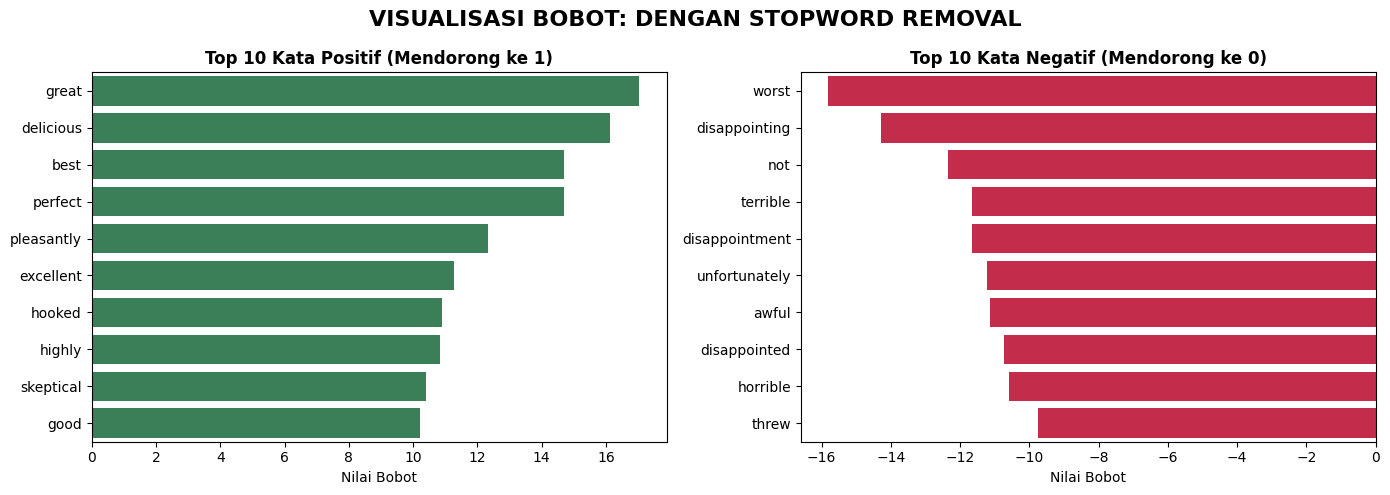

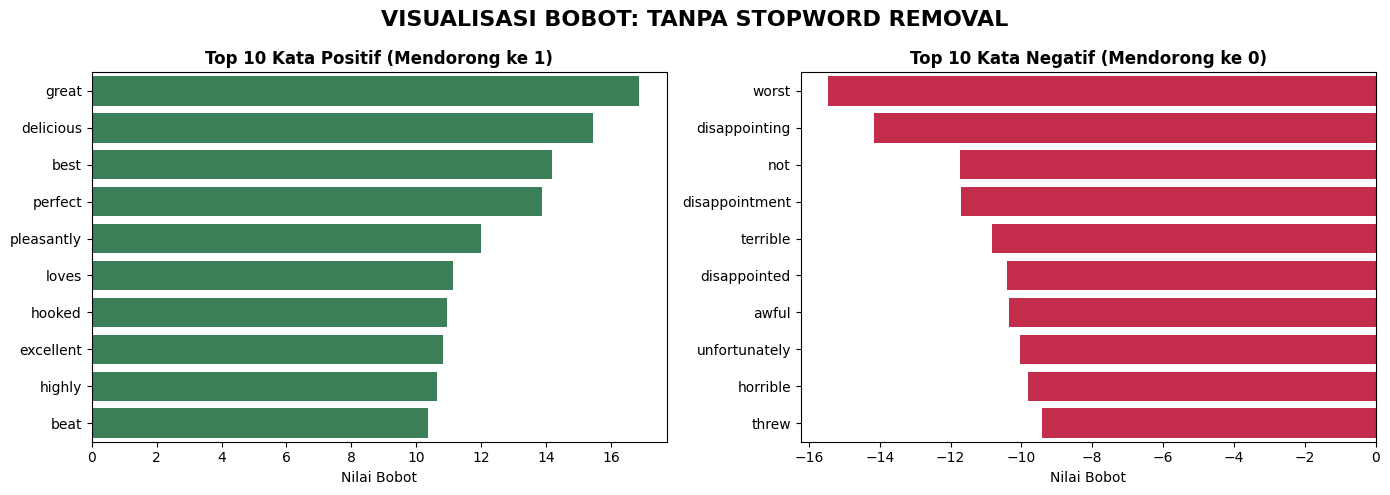

In [29]:
def visualisasi_bobot_model(vectorizer, model, judul):
    # 1. Mengambil kata dan bobot
    fitur_kata = vectorizer.get_feature_names_out()
    bobot_kata = model.coef_[0]

    df_analisis = pd.DataFrame({'Kata': fitur_kata, 'Bobot': bobot_kata})
    df_urut = df_analisis.sort_values(by='Bobot', ascending=False)

    # 2. Pisahkan Top 10 Positif dan Top 10 Negatif
    top_positif = df_urut.head(10)
    top_negatif = df_urut.tail(10).sort_values(by='Bobot', ascending=True) # Urutkan dari minus terdalam

    # 3. Membuat Canvas Visualisasi (1 baris, 2 kolom)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(judul, fontsize=16, fontweight='bold')

    # Grafik Kiri: Kata Positif (Warna Hijau)
    sns.barplot(x='Bobot', y='Kata', data=top_positif, ax=axes[0], color='seagreen')
    axes[0].set_title('Top 10 Kata Positif (Mendorong ke 1)', fontweight='bold')
    axes[0].set_xlabel('Nilai Bobot')
    axes[0].set_ylabel('')

    # Grafik Kanan: Kata Negatif (Warna Merah)
    sns.barplot(x='Bobot', y='Kata', data=top_negatif, ax=axes[1], color='crimson')
    axes[1].set_title('Top 10 Kata Negatif (Mendorong ke 0)', fontweight='bold')
    axes[1].set_xlabel('Nilai Bobot')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

# Panggil fungsinya
visualisasi_bobot_model(tfidf_with_stopwords, model2_with, "VISUALISASI BOBOT: DENGAN STOPWORD REMOVAL")
visualisasi_bobot_model(tfidf_without_stopwords, model2_without, "VISUALISASI BOBOT: TANPA STOPWORD REMOVAL")

**BOBOT MODEL 3**

In [30]:
def analisis_bobot_pipeline(pipeline_model, judul):
    vectorizer = pipeline_model.named_steps['tfidf']
    model_lr = pipeline_model.named_steps['lr']

    # Mengambil daftar kata dan nilai bobot dari model di dalam pipeline
    fitur_kata = vectorizer.get_feature_names_out()
    bobot_kata = model_lr.coef_[0]

    # Memasukkan ke dalam tabel (DataFrame)
    df_analisis = pd.DataFrame({
        'Kata': fitur_kata,
        'Bobot': bobot_kata
    })

    # Mengurutkan berdasarkan bobot tertinggi ke terendah
    df_urut = df_analisis.sort_values(by='Bobot', ascending=False)

    print(f"\n{judul}")
    print("-" * 50)
    print("10 KATA POSITIF TERTINGGI (Mendorong tebakan ke Kelas 1)")
    display(df_urut.head(10).reset_index(drop=True))

    print("\n10 KATA NEGATIF TERTINGGI(Mendorong tebakan ke Kelas 0)")
    display(df_urut.tail(10).sort_values(by='Bobot').reset_index(drop=True))
    print("=" * 50)

# 1. Model 3 DENGAN Stopword (Teks Utuh)
analisis_bobot_pipeline(pipeline_with, "=== BOBOT: MODEL 3 DENGAN STOPWORD ===")

# 2. Model 3 TANPA Stopword (Teks Bersih)
analisis_bobot_pipeline(pipeline_without, "=== BOBOT: MODEL 3 TANPA STOPWORD ===")


=== BOBOT: MODEL 3 DENGAN STOPWORD ===
--------------------------------------------------
10 KATA POSITIF TERTINGGI (Mendorong tebakan ke Kelas 1)


,Kata,Bobot
0,great,15.204464
1,best,13.579352
2,delicious,12.832828
3,perfect,12.684121
4,highly,9.915699
5,hooked,9.791215
6,excellent,9.624615
7,pleasantly,9.551194
8,yummy,9.353684
9,beat,9.010501



10 KATA NEGATIF TERTINGGI(Mendorong tebakan ke Kelas 0)


,Kata,Bobot
0,worst,-14.198070
1,disappointing,-13.163848
2,disappointment,-10.627660
3,not,-10.454452
4,disappointed,-10.388747
5,awful,-10.145839
6,terrible,-9.954786
7,unfortunately,-8.928153
8,horrible,-8.821999
9,yuck,-8.413835



=== BOBOT: MODEL 3 TANPA STOPWORD ===
--------------------------------------------------
10 KATA POSITIF TERTINGGI (Mendorong tebakan ke Kelas 1)


,Kata,Bobot
0,great,13.744906
1,best,12.458981
2,delicious,12.301903
3,perfect,11.533931
4,hooked,9.788889
5,loves,9.781663
6,highly,9.331694
7,pleasantly,9.237125
8,excellent,8.898770
9,beat,8.701816



10 KATA NEGATIF TERTINGGI(Mendorong tebakan ke Kelas 0)


,Kata,Bobot
0,worst,-12.915175
1,disappointing,-12.234544
2,not,-10.151298
3,disappointment,-10.149773
4,disappointed,-9.233863
5,terrible,-9.051490
6,awful,-8.934634
7,unfortunately,-8.020395
8,horrible,-8.014538
9,threw,-7.712660


**Visualisasi bobot Model 3**

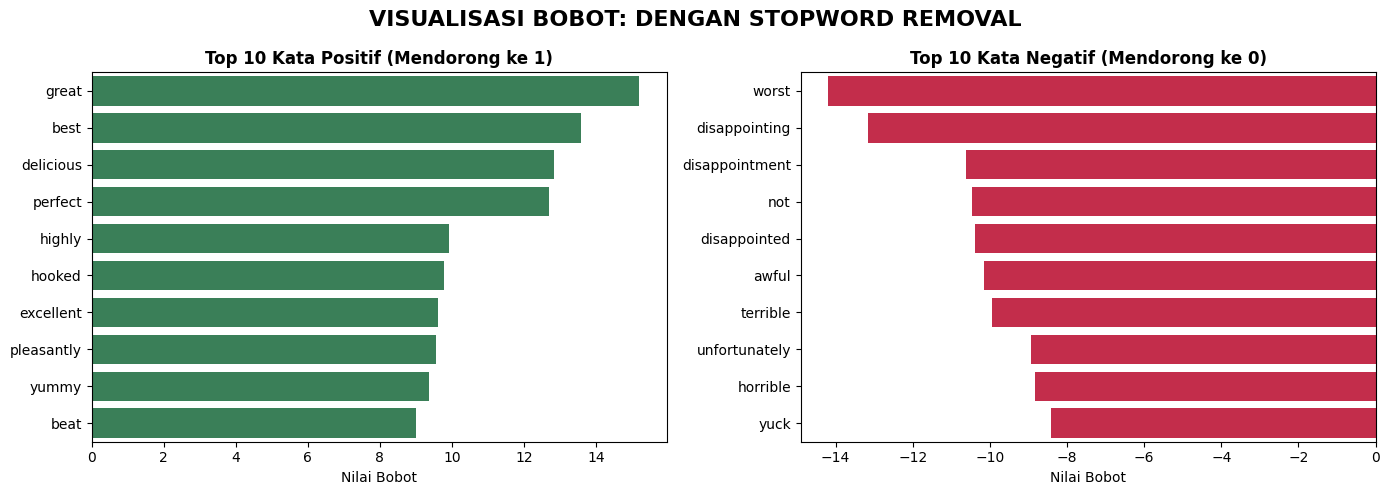

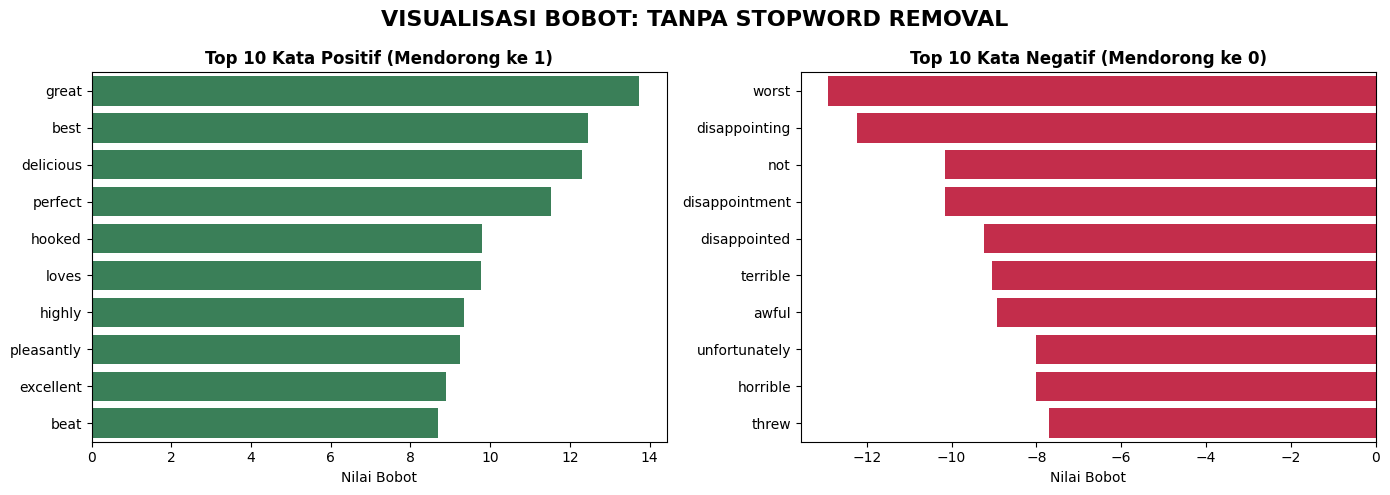

In [31]:
def visualisasi_bobot_model(vectorizer, model, judul):
    # 1. Mengambil kata dan bobot
    fitur_kata = vectorizer.get_feature_names_out()
    # Access the LogisticRegression model within the pipeline
    bobot_kata = model.named_steps['lr'].coef_[0]

    df_analisis = pd.DataFrame({'Kata': fitur_kata, 'Bobot': bobot_kata})
    df_urut = df_analisis.sort_values(by='Bobot', ascending=False)

    # 2. Pisahkan Top 10 Positif dan Top 10 Negatif
    top_positif = df_urut.head(10)
    top_negatif = df_urut.tail(10).sort_values(by='Bobot', ascending=True) # Urutkan dari minus terdalam

    # 3. Membuat Canvas Visualisasi (1 baris, 2 kolom)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(judul, fontsize=16, fontweight='bold')

    # Grafik Kiri: Kata Positif (Warna Hijau)
    sns.barplot(x='Bobot', y='Kata', data=top_positif, ax=axes[0], color='seagreen')
    axes[0].set_title('Top 10 Kata Positif (Mendorong ke 1)', fontweight='bold')
    axes[0].set_xlabel('Nilai Bobot')
    axes[0].set_ylabel('')

    # Grafik Kanan: Kata Negatif (Warna Merah)
    sns.barplot(x='Bobot', y='Kata', data=top_negatif, ax=axes[1], color='crimson')
    axes[1].set_title('Top 10 Kata Negatif (Mendorong ke 0)', fontweight='bold')
    axes[1].set_xlabel('Nilai Bobot')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

# Panggil fungsinya
visualisasi_bobot_model(tfidf_with_stopwords, pipeline_with, "VISUALISASI BOBOT: DENGAN STOPWORD REMOVAL")
visualisasi_bobot_model(tfidf_without_stopwords, pipeline_without, "VISUALISASI BOBOT: TANPA STOPWORD REMOVAL")

# Exporting

In [32]:
import pickle
from google.colab import files

# 1. Simpan Model Logistic Regression
model_ml_filename = 'logistic_regression_model.pickle'
with open(model_ml_filename, 'wb') as f:
    pickle.dump(model1_with, f)

# 2. Simpan TF-IDF Vectorizer
tfidf_filename = 'tfidf_vectorizer.pickle'
with open(tfidf_filename, 'wb') as f:
    pickle.dump(tfidf_with_stopwords, f)

print("[SUKSES] Model dan TF-IDF berhasil diekspor!")

# Download file ke komputer lokal
files.download(model_ml_filename)
files.download(tfidf_filename)

[SUKSES] Model dan TF-IDF berhasil diekspor!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>